# Second-Order Adversarial Attacks on CNNs
## From Gradient Steps to Optimization — L-BFGS and the Carlini-Wagner Attack

*Part 2 of the AI Security Series by **Camilo Pestana, PhD***

---

## Recap — Part 1

In Part 1 we studied **FGSM** and **PGD** — both *first-order* attacks:

| Attack | Steps | Core operation |
|--------|-------|----------------|
| FGSM | 1 | $x_{adv} = x + \epsilon \cdot \text{sign}(\nabla_x J)$ |
| PGD | T | Repeat gradient step + project back into $\epsilon$-ball |

Both attacks **fix $\epsilon$ first** (the perturbation budget) and then find the most damaging image *within* that budget. They only use the **gradient direction** — first-order information.

---

## The Key Limitation of First-Order Attacks

First-order methods follow the gradient direction, but the gradient is only a **local linear approximation** of the loss surface. Two problems arise:

1. **Suboptimal step sizes**: Gradient descent/ascent has no sense of *curvature* — it might take huge steps in flat regions and tiny steps in curved ones.
2. **Fixed budget framing**: You must specify $\epsilon$ upfront. But how do you know the *minimum* perturbation needed? FGSM could be using far more distortion than necessary.

**Second-order methods** address both problems by incorporating **curvature** (second derivatives) into the update rule.

---

## Newton's Method — The Intuition

Newton's method replaces the gradient step with a **curvature-corrected** step:

$$\text{Gradient descent:} \quad x_{t+1} = x_t - \alpha \cdot \nabla f(x_t)$$

$$\text{Newton's method:} \quad x_{t+1} = x_t - \left[\nabla^2 f(x_t)\right]^{-1} \nabla f(x_t)$$

The **Hessian** $\nabla^2 f$ (matrix of second derivatives) captures the local curvature:
- In flat regions (small curvature) → take larger steps
- In curved regions (large curvature) → take smaller, more precise steps

This leads to **quadratic convergence** vs linear convergence for gradient descent.

### The Problem: Hessian is Huge

For a 224×224×3 image, the full Hessian has $(224 \times 224 \times 3)^2 \approx 2.3 \times 10^{10}$ elements — impossible to store or invert.

**Solution**: Use *approximations* of the Hessian:
- **L-BFGS**: approximates $H^{-1}$ using recent gradient history (quasi-Newton)
- **Adam optimizer** (used in C&W): uses diagonal curvature approximation via gradient moments

---

## Attacks Covered in This Notebook

| Attack | Author | Optimizer | Norm | Key Idea |
|--------|--------|-----------|------|----------|
| **L-BFGS** | Szegedy et al., 2013 | L-BFGS (quasi-Newton) | L₂ | First ever adversarial attack — minimize distance while fooling model |
| **C&W** | Carlini & Wagner, 2017 | Adam | L₂ | Custom objective + Adam — finds minimal perturbation reliably |

---
## Section 1: Setup

In [1]:
import os, json, tarfile, warnings, urllib.request, time

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import requests
from PIL import Image
from io import BytesIO
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, ConcatDataset, Subset
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder

warnings.filterwarnings('ignore')

# ── Device ────────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'CUDA: {torch.cuda.get_device_name(0)}')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print('MPS: Apple Silicon GPU')
else:
    device = torch.device('cpu')
    print('CPU — Note: C&W/L-BFGS are slow on CPU; reduce max_iter if needed')

torch.manual_seed(42)
np.random.seed(42)

# ── ImageNet normalization ─────────────────────────────────────────────────────
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

preprocess = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])
inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip(MEAN, STD)],
    std=[1/s for s in STD]
)
LOWER = torch.tensor([(0-m)/s for m,s in zip(MEAN,STD)], device=device).view(1,3,1,1)
UPPER = torch.tensor([(1-m)/s for m,s in zip(MEAN,STD)], device=device).view(1,3,1,1)

def tensor_to_image(t):
    img = inv_normalize(t.squeeze(0).cpu().detach()).permute(1,2,0).numpy()
    return np.clip(img, 0, 1)

def img_panel(ax, img, title, subtitle='', cmap=None, border_color='#2c3e50'):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title, fontsize=10, fontweight='bold', pad=4, color=border_color)
    if subtitle: ax.set_xlabel(subtitle, fontsize=8, color='#555', labelpad=3)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_edgecolor(border_color); sp.set_linewidth(2.5)

print('Setup complete!')

MPS: Apple Silicon GPU
Setup complete!


---
## Section 2: Load Model, Panda Image and Dataset

In [2]:
# ── ResNet50 ──────────────────────────────────────────────────────────────────
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1).to(device).eval()
print(f'ResNet50 loaded — {sum(p.numel() for p in model.parameters()):,} parameters')

# ── ImageNet labels ───────────────────────────────────────────────────────────
class_index   = requests.get(
    'https://storage.googleapis.com/download.tensorflow.org/data/imagenet_class_index.json',
    timeout=30).json()
synset_to_idx = {v[0]: int(k) for k,v in class_index.items()}
idx_to_label  = {int(k): v[1].replace('_',' ') for k,v in class_index.items()}

# ── Panda image ───────────────────────────────────────────────────────────────
HEADERS = {'User-Agent': 'Mozilla/5.0 (educational-notebook; adversarial-ml)'}
PANDA_URLS = [
    'https://raw.githubusercontent.com/EliSchwartz/imagenet-sample-images/master/n02510455_giant_panda.JPEG',
    'https://upload.wikimedia.org/wikipedia/commons/0/0f/Grosser_Panda.JPG',
]
panda_pil = None
for url in PANDA_URLS:
    try:
        r = requests.get(url, headers=HEADERS, timeout=20); r.raise_for_status()
        panda_pil = Image.open(BytesIO(r.content)).convert('RGB')
        print(f'Panda loaded: {panda_pil.size}'); break
    except Exception as e:
        print(f'  Failed: {e}')

panda_tensor = preprocess(panda_pil).unsqueeze(0).to(device)
panda_idx    = synset_to_idx.get('n02510455', 388)
panda_label  = torch.tensor([panda_idx], device=device)

with torch.no_grad():
    p = F.softmax(model(panda_tensor), dim=1)
pred = p.argmax(dim=1).item()
print(f'Clean prediction: {idx_to_label[pred]} ({p[0,pred]:.2%})')

ResNet50 loaded — 25,557,032 parameters
Panda loaded: (500, 375)
Clean prediction: giant panda (99.99%)


In [3]:
# ── Download Imagenette + Imagewoof (20 ImageNet classes) ─────────────────────
def download_and_extract(name, url, data_dir='./data'):
    os.makedirs(data_dir, exist_ok=True)
    path = os.path.join(data_dir, name)
    if os.path.exists(path):
        print(f'  {name}: already present'); return path
    tgz = os.path.join(data_dir, f'{name}.tgz')
    print(f'  Downloading {name}...')
    with tqdm(unit='B', unit_scale=True, unit_divisor=1024, desc=name) as t:
        urllib.request.urlretrieve(url, tgz,
            lambda b,bs,ts: t.update(bs) or setattr(t, 'total', ts))
    with tarfile.open(tgz, 'r:gz') as tar: tar.extractall(data_dir)
    os.remove(tgz)
    return path

imagenette_path = download_and_extract('imagenette2-160',
    'https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-160.tgz')
imagewoof_path  = download_and_extract('imagewoof2-160',
    'https://s3.amazonaws.com/fast-ai-imageclas/imagewoof2-160.tgz')

IMAGENETTE_SYNSETS = ['n01440764','n02102040','n02979186','n03000684','n03028079',
                      'n03394916','n03417042','n03425413','n03445777','n03888257']
IMAGEWOOF_SYNSETS  = ['n02086240','n02087394','n02088364','n02089973','n02093754',
                      'n02096294','n02099601','n02105641','n02111889','n02115641']
synset_to_imagenet = {s: synset_to_idx[s]
                      for s in IMAGENETTE_SYNSETS + IMAGEWOOF_SYNSETS
                      if s in synset_to_idx}

class ImageNetSubset(Dataset):
    def __init__(self, root, mapping, transform=None):
        self.base = ImageFolder(root, transform=transform)
        self.targets = [mapping[self.base.classes[t]] for t in self.base.targets]
    def __len__(self): return len(self.base)
    def __getitem__(self, i):
        img, _ = self.base[i]; return img, self.targets[i]

eval_tf = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224),
    transforms.ToTensor(), transforms.Normalize(mean=MEAN, std=STD)
])
nette_val = ImageNetSubset(os.path.join(imagenette_path,'val'),
    {s: synset_to_imagenet[s] for s in IMAGENETTE_SYNSETS}, eval_tf)
woof_val  = ImageNetSubset(os.path.join(imagewoof_path,'val'),
    {s: synset_to_imagenet[s] for s in IMAGEWOOF_SYNSETS}, eval_tf)

N = 50  # 50 per dataset = 100 total
eval_dataset = ConcatDataset([
    Subset(nette_val, list(range(min(N, len(nette_val))))),
    Subset(woof_val,  list(range(min(N, len(woof_val)))))
])
eval_loader = DataLoader(eval_dataset, batch_size=1, shuffle=False, num_workers=0)
print(f'Evaluation set: {len(eval_dataset)} images (100 total, 20 classes)')

  imagenette2-160: already present
  imagewoof2-160: already present
Evaluation set: 100 images (100 total, 20 classes)


---
## Section 3: First-Order Baselines (Recap)

We keep FGSM and PGD as reference points for the comparison.

In [4]:
@torch.enable_grad()
def fgsm(model, image, label, epsilon):
    """FGSM — one gradient step (first-order)."""
    adv = image.clone().detach().requires_grad_(True)
    F.cross_entropy(model(adv), label).backward()
    return torch.clamp(adv + epsilon * adv.grad.sign(), LOWER, UPPER).detach()

@torch.enable_grad()
def pgd(model, image, label, epsilon, alpha=None, steps=40):
    """PGD — iterative gradient steps with projection (first-order)."""
    if alpha is None: alpha = epsilon / 4
    delta = torch.empty_like(image).uniform_(-epsilon, epsilon)
    delta = torch.clamp(image + delta, LOWER, UPPER) - image
    adv   = (image + delta).detach()
    for _ in range(steps):
        adv.requires_grad_(True)
        F.cross_entropy(model(adv), label).backward()
        with torch.no_grad():
            adv = torch.clamp(adv + alpha * adv.grad.sign(),
                              image - epsilon, image + epsilon)
            adv = torch.clamp(adv, LOWER, UPPER)
        adv = adv.detach()
    return adv

print('FGSM and PGD ready.')

FGSM and PGD ready.


---
## Section 4: The L-BFGS Attack
### Szegedy et al., 2013 — *"Intriguing Properties of Neural Networks"*

This is the **original adversarial attack paper**. The authors discovered that tiny, human-invisible perturbations could fool neural networks — and they used L-BFGS to find them.

### What is L-BFGS?

**BFGS** (Broyden–Fletcher–Goldfarb–Shanno) is a quasi-Newton optimization algorithm. Instead of computing the full Hessian (too large), it **approximates $H^{-1}$** using the history of gradient changes:

$$x_{t+1} = x_t - H_t^{-1} \nabla f(x_t)$$

where $H_t^{-1}$ is built from the last $m$ gradient pairs. **L-BFGS** is the *limited-memory* version — it only stores the last $m$ (typically 5–20) gradient updates instead of the full matrix.

### The Attack Objective

$$\min_{\delta} \; c \|\delta\|_2^2 \;-\; \mathcal{L}(x + \delta,\, y)$$

- $c \|\delta\|_2^2$ → keep the perturbation small (L2 regularisation)
- $-\mathcal{L}$ → negate the cross-entropy loss, so **minimising** this term **maximises** the loss → causes misclassification
- $c$ balances distortion vs attack effectiveness

The curvature-aware steps of L-BFGS find a **much smaller** $\|\delta\|_2$ than FGSM at the same attack success rate.

In [5]:
@torch.enable_grad()
def lbfgs_attack(model, image, label, c=0.1, kappa=0.0, max_iter=300):
    """
    L-BFGS adversarial attack (Szegedy et al., 2013).

    Uses PyTorch's built-in L-BFGS optimizer (quasi-Newton / second-order).

    Objective: minimize  c·||δ||₂²  +  f(x+δ)
    where  f = max(Z[true] - max_{j≠true} Z[j] + κ, 0)
      f = 0  →  attack succeeded (model predicts wrong class)
    Logit-margin loss avoids the gradient saturation of cross-entropy
    at high-confidence predictions (e.g. 99.99% panda).

    Args:
        c        : weight on the L2 regularisation (larger c = smaller δ)
        kappa    : confidence margin for misclassification (0 = just wrong)
        max_iter : L-BFGS iterations (function evaluations in strong Wolfe)
    """
    delta = torch.zeros_like(image, requires_grad=True)
    optimizer = torch.optim.LBFGS(
        [delta], lr=1.0, max_iter=max_iter,
        tolerance_grad=1e-7, tolerance_change=1e-9,
        line_search_fn='strong_wolfe'
    )

    def closure():
        optimizer.zero_grad()
        adv    = torch.clamp(image + delta, LOWER, UPPER)
        logits = model(adv)
        # Logit-margin loss — does NOT saturate at high-confidence predictions
        Z_true = logits[0, label[0]]
        mask   = torch.ones(logits.size(1), dtype=torch.bool, device=device)
        mask[label[0]] = False
        Z_max_other = logits[0][mask].max()
        f_val = torch.clamp(Z_true - Z_max_other + kappa, min=0.0)
        loss  = c * (delta ** 2).sum() + f_val
        loss.backward()
        return loss

    optimizer.step(closure)

    with torch.no_grad():
        adv = torch.clamp(image + delta, LOWER, UPPER)
    return adv.detach()


# ── Demo on panda ─────────────────────────────────────────────────────────────
print('Running L-BFGS on panda...')
t0 = time.time()
adv_lbfgs = lbfgs_attack(model, panda_tensor, panda_label, c=0.1, kappa=0.0, max_iter=300)
t_lbfgs   = time.time() - t0

with torch.no_grad():
    p_lbfgs = F.softmax(model(adv_lbfgs), dim=1)[0]

pred_lbfgs = p_lbfgs.argmax().item()
l2_lbfgs   = (adv_lbfgs - panda_tensor).pow(2).sum().sqrt().item()

print(f'L-BFGS result : {idx_to_label[pred_lbfgs]} ({p_lbfgs[pred_lbfgs]:.2%})')
print(f'L2 distortion : {l2_lbfgs:.4f}')
print(f'Panda conf    : {p_lbfgs[panda_idx]:.2%}')
print(f'Time          : {t_lbfgs:.2f}s')


Running L-BFGS on panda...
L-BFGS result : lesser panda (49.30%)
L2 distortion : 2.7444
Panda conf    : 49.30%
Time          : 16.50s


---
## Section 5: The Carlini-Wagner (C&W) Attack
### Carlini & Wagner, 2017 — *"Evaluating the Robustness of Neural Networks"*

C&W is widely considered the **strongest practical optimization-based attack** and remains the gold standard for evaluating model robustness.

### The Clever Objective

Previous attacks defined adversarial examples inside an $\epsilon$-ball. C&W instead directly minimises the **L2 distance** subject to causing a misclassification:

$$\min_{\delta} \; \|\delta\|_2^2 \;+\; c \cdot f(x + \delta)$$

where the attack-success function $f$ is:

$$f(x_{adv}) = \max\!\left(\, Z_{true}(x_{adv}) - \max_{j \neq \text{true}} Z_j(x_{adv}) + \kappa,\; 0 \right)$$

- $Z$ = logits (pre-softmax outputs)
- $f = 0$ exactly when the attack **has succeeded** (model predicts wrong class)
- $\kappa$ = confidence margin — how far the wrong class should beat the true class
- $c$ = balance between distortion and attack effectiveness

### Why This Objective is Clever

| Issue with naïve objectives | C&W solution |
|-----------------------------|--------------|
| Gradient vanishes when model is correct | Logit-based $f$ never saturates |
| Hard to balance distortion vs success | Binary search on $c$ |
| Box constraint $[0,1]^n$ hard to enforce | Clip after each Adam step |

### Optimizer: Adam (Diagonal Curvature Approximation)

Adam maintains **per-parameter adaptive learning rates** based on the first and second gradient moments — effectively a diagonal approximation of the Hessian. This gives it second-order-like behaviour without the full $O(n^2)$ Hessian cost.

In [6]:
@torch.enable_grad()
def cw_l2_attack(model, image, label, c=1.0, kappa=0.0,
                  max_iter=500, lr=0.01):
    """
    C&W L2 adversarial attack — Carlini & Wagner (2017).

    Finds the minimum L2 perturbation δ such that model(x+δ) ≠ true_label.

    Objective: min  ||δ||₂²  +  c · f(x+δ)
    where f(x_adv) = max(Z[true] - max_{j≠true} Z[j] + κ, 0)
       f = 0  →  attack succeeded (model predicts wrong class)

    Args:
        c        : attack strength (larger = more likely to succeed but larger distortion)
        kappa    : confidence margin for the misclassification (0 = just barely wrong)
        max_iter : Adam optimization steps
        lr       : Adam learning rate

    Returns:
        best_adv     : adversarial image with smallest L2 that caused misclassification
        best_l2      : L2 norm of the perturbation
        loss_history : list of per-iteration losses for visualization
    """
    delta     = torch.zeros_like(image, requires_grad=True)
    optimizer = torch.optim.Adam([delta], lr=lr)

    best_adv = image.clone()
    best_l2  = float('inf')
    history  = {'total': [], 'l2': [], 'f': []}

    for i in range(max_iter):
        adv    = torch.clamp(image + delta, LOWER, UPPER)
        logits = model(adv)

        # f(x_adv): 0 when attack succeeds, > 0 while still correct
        Z_true      = logits[0, label[0]]
        mask        = torch.ones(logits.size(1), dtype=torch.bool, device=device)
        mask[label[0]] = False
        Z_max_other = logits[0][mask].max()
        f_val       = torch.clamp(Z_true - Z_max_other + kappa, min=0.0)

        l2_sq = (delta ** 2).sum()
        loss  = l2_sq + c * f_val

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        history['total'].append(loss.item())
        history['l2'].append(l2_sq.sqrt().item())
        history['f'].append(f_val.item())

        # Save the best (smallest L2) adversarial example found so far
        with torch.no_grad():
            adv_eval = torch.clamp(image + delta, LOWER, UPPER)
            pred     = model(adv_eval).argmax(dim=1).item()
            curr_l2  = (adv_eval - image).pow(2).sum().sqrt().item()
            if pred != label.item() and curr_l2 < best_l2:
                best_l2  = curr_l2
                best_adv = adv_eval.clone()

    # If attack never caused misclassification, return the last iterate
    # (shows partial perturbation rather than the unchanged original)
    if best_l2 == float('inf'):
        with torch.no_grad():
            best_adv = torch.clamp(image + delta, LOWER, UPPER)
        best_l2 = (best_adv - image).pow(2).sum().sqrt().item()

    return best_adv, best_l2, history

print('C&W attack function ready.')

C&W attack function ready.


Running C&W on panda (1000 iterations, c=50)...
C&W result    : lesser panda (97.78%)
Best L2       : 5.2075  (inf = attack did not succeed yet)
Panda conf    : 1.35%
Time          : 36.17s


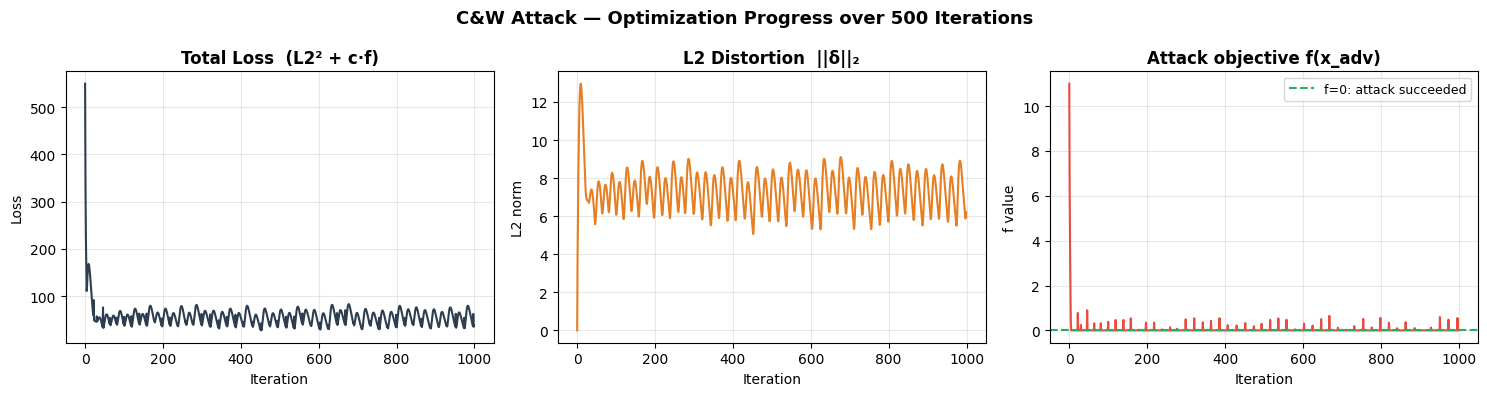


When f reaches 0 (green dashed line), the attack has succeeded.


In [7]:
# ── Run C&W on panda ──────────────────────────────────────────────────────────
print('Running C&W on panda (1000 iterations, c=50)...')
t0 = time.time()
adv_cw, cw_l2, cw_history = cw_l2_attack(
    model, panda_tensor, panda_label, c=50.0, kappa=0, max_iter=1000, lr=0.01
)
t_cw = time.time() - t0

with torch.no_grad():
    p_cw = F.softmax(model(adv_cw), dim=1)[0]
pred_cw = p_cw.argmax().item()

print(f'C&W result    : {idx_to_label[pred_cw]} ({p_cw[pred_cw]:.2%})')
print(f'Best L2       : {cw_l2:.4f}  (inf = attack did not succeed yet)')
print(f'Panda conf    : {p_cw[panda_idx]:.2%}')
print(f'Time          : {t_cw:.2f}s')

# ── Loss evolution plot ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('C&W Attack — Optimization Progress over 500 Iterations',
             fontsize=13, fontweight='bold')
iters = range(len(cw_history['total']))

axes[0].plot(iters, cw_history['total'], color='#2c3e50', lw=1.5)
axes[0].set_title('Total Loss  (L2² + c·f)', fontweight='bold')
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(iters, cw_history['l2'], color='#e67e22', lw=1.5)
axes[1].set_title('L2 Distortion  ||δ||₂', fontweight='bold')
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('L2 norm')
axes[1].grid(True, alpha=0.3)

axes[2].plot(iters, cw_history['f'], color='#e74c3c', lw=1.5)
axes[2].axhline(0, color='#27ae60', ls='--', lw=1.5, label='f=0: attack succeeded')
axes[2].set_title('Attack objective f(x_adv)', fontweight='bold')
axes[2].set_xlabel('Iteration'); axes[2].set_ylabel('f value')
axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cw_loss_evolution.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nWhen f reaches 0 (green dashed line), the attack has succeeded.')

---
## Section 6: Visual Comparison — FGSM vs PGD vs L-BFGS vs C&W

We compare all four attacks at roughly comparable settings. Note the key metric difference:

- **FGSM / PGD**: controlled by $\epsilon$ (L∞ bound)
- **L-BFGS / C&W**: minimise L2 distortion — no fixed $\epsilon$ needed

Generating adversarial examples...


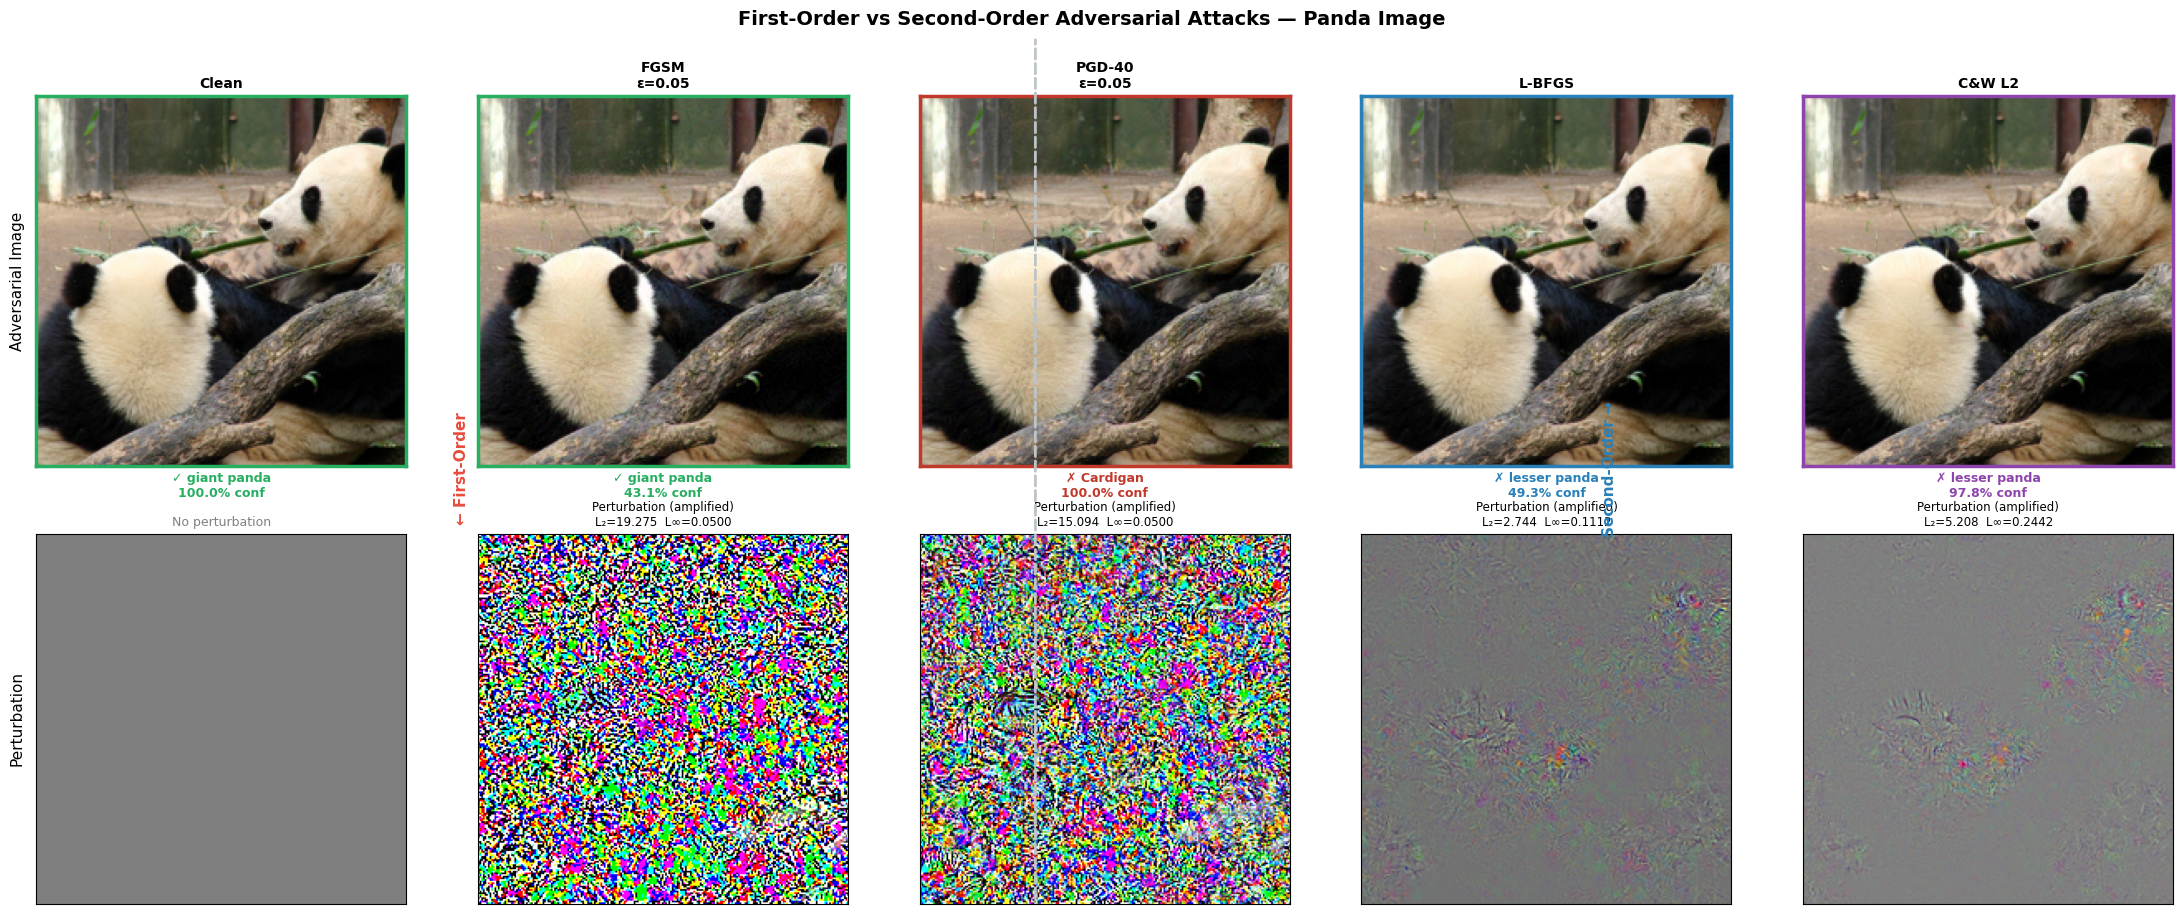

In [8]:
EPS = 0.05  # for FGSM / PGD

# Generate all adversarial images
print('Generating adversarial examples...')
adv_fgsm  = fgsm(model, panda_tensor, panda_label, epsilon=EPS)
adv_pgd   = pgd(model,  panda_tensor, panda_label, epsilon=EPS, steps=40)
# L-BFGS and C&W were already computed above

def get_pred_conf(adv):
    with torch.no_grad():
        p = F.softmax(model(adv), dim=1)[0]
    pred = p.argmax().item()
    return idx_to_label[pred], p[pred].item(), p[panda_idx].item(), pred != panda_idx

attacks = [
    ('Clean',           panda_tensor, None,       '#27ae60'),
    (f'FGSM\nε={EPS}',  adv_fgsm,    adv_fgsm,   '#e74c3c'),
    (f'PGD-40\nε={EPS}',adv_pgd,     adv_pgd,    '#c0392b'),
    ('L-BFGS',          adv_lbfgs,   adv_lbfgs,  '#2980b9'),
    ('C&W L2',          adv_cw,      adv_cw,     '#8e44ad'),
]

fig, axes = plt.subplots(2, len(attacks), figsize=(4.5*len(attacks), 9))
fig.suptitle('First-Order vs Second-Order Adversarial Attacks — Panda Image',
             fontsize=14, fontweight='bold', y=1.01)

for col, (name, adv, adv_orig, color) in enumerate(attacks):
    label_str, conf, panda_conf, fooled = get_pred_conf(adv)
    c   = '#27ae60' if not fooled else color
    sym = '✓' if not fooled else '✗'

    # Row 0: adversarial image
    axes[0, col].imshow(tensor_to_image(adv))
    axes[0, col].set_title(name, fontsize=10, fontweight='bold')
    axes[0, col].set_xlabel(
        f'{sym} {label_str[:16]}\n{conf:.1%} conf',
        fontsize=9, color=c, fontweight='bold'
    )
    axes[0, col].set_xticks([]); axes[0, col].set_yticks([])
    for sp in axes[0, col].spines.values(): sp.set_edgecolor(c); sp.set_linewidth(2.5)

    # Row 1: perturbation (amplified)
    if adv_orig is None:
        axes[1, col].imshow(np.ones((224,224,3))*0.5)
        axes[1, col].set_title('No perturbation', fontsize=9, color='gray')
    else:
        diff     = (adv_orig - panda_tensor).squeeze(0).cpu().numpy().transpose(1,2,0)
        l2       = np.sqrt((diff**2).sum())
        linf     = np.abs(diff).max()
        diff_vis = (diff - diff.min()) / (diff.max() - diff.min() + 1e-8)
        axes[1, col].imshow(diff_vis)
        axes[1, col].set_title(
            f'Perturbation (amplified)\nL₂={l2:.3f}  L∞={linf:.4f}',
            fontsize=8.5
        )
    axes[1, col].set_xticks([]); axes[1, col].set_yticks([])

axes[0, 0].set_ylabel('Adversarial Image', fontsize=11, labelpad=8)
axes[1, 0].set_ylabel('Perturbation',      fontsize=11, labelpad=8)

# ── First-order / Second-order group labels (horizontal, below the grid) ──
fig.text(0.37, -0.02, '◄── First-Order ──►',
         ha='center', va='top', fontsize=11, color='#e74c3c', fontweight='bold')
fig.text(0.745, -0.02, '◄── Second-Order ──►',
         ha='center', va='top', fontsize=11, color='#2980b9', fontweight='bold')

plt.tight_layout()
plt.savefig('first_vs_second_order_panda.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Section 7: Dataset Evaluation — 100 Images, 20 Classes

We evaluate all four attacks on the dataset, tracking:
- **Accuracy** (lower = stronger attack)
- **Mean L2 distortion** (lower = more imperceptible)
- **Computation time**

> **Note**: C&W runs the optimizer per image (no batching), so it is significantly slower than FGSM/PGD. This is one of its key practical limitations.

In [ ]:
@torch.enable_grad()
def evaluate(model, dataloader, attack_fn, attack_name):
    """
    Evaluate an attack on the dataset.
    attack_fn(image, label) -> adversarial_image
    Returns: accuracy, mean_l2, elapsed_seconds
    """
    model.eval()
    correct = 0; total = 0; total_l2 = 0.0
    t0 = time.time()

    for images, labels in tqdm(dataloader, desc=attack_name, leave=False):
        images = images.to(device)
        labels = labels.to(device)

        if attack_fn is not None:
            adv = attack_fn(images, labels)
        else:
            adv = images

        l2 = (adv - images).pow(2).sum(dim=(1,2,3)).sqrt().mean().item()
        total_l2 += l2

        with torch.no_grad():
            preds = model(adv).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

    return correct/total, total_l2/len(dataloader), time.time()-t0


EPS_EVAL = 0.05

attack_configs = [
    ('Clean',    None),
    ('FGSM',     lambda img,lbl: fgsm(model, img, lbl, EPS_EVAL)),
    ('PGD-40',   lambda img,lbl: pgd(model, img, lbl, EPS_EVAL, steps=40)),
    ('L-BFGS',   lambda img,lbl: lbfgs_attack(model, img, lbl, c=0.1, kappa=0.0, max_iter=100)),
    ('C&W L2',   lambda img,lbl: cw_l2_attack(model, img, lbl, c=10.0,
                                               max_iter=200, lr=0.01)[0]),
]

results = {}
print(f'Evaluating on {len(eval_dataset)} images (ε={EPS_EVAL} for FGSM/PGD)...\n')
for name, fn in attack_configs:
    acc, mean_l2, elapsed = evaluate(model, eval_loader, fn, name)
    results[name] = {'acc': acc, 'l2': mean_l2, 'time': elapsed}
    print(f'{name:10s}  acc={acc:.2%}  mean_L2={mean_l2:.4f}  time={elapsed:.1f}s')

print('\nDone!')

Evaluating on 100 images (ε=0.05 for FGSM/PGD)...



Clean       acc=80.00%  mean_L2=0.0000  time=1.3s


FGSM        acc=10.00%  mean_L2=19.3363  time=3.4s


PGD-40      acc=0.00%  mean_L2=14.3822  time=83.8s


L-BFGS      acc=48.00%  mean_L2=0.8364  time=204.6s


C&W L2:   0%|                                           | 0/100 [00:00<?, ?it/s]

---
## Section 8: Analysis — First-Order vs Second-Order

In [ ]:
names      = list(results.keys())
accs       = [results[n]['acc']*100       for n in names]
l2s        = [results[n]['l2']            for n in names]
times      = [results[n]['time']          for n in names]
success    = [100 - a                     for a in accs]

COLORS = {'Clean':'#27ae60','FGSM':'#e74c3c','PGD-40':'#c0392b',
          'L-BFGS':'#2980b9','C&W L2':'#8e44ad'}
bar_colors = [COLORS[n] for n in names]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('First-Order vs Second-Order Attacks — Full Comparison\n'
             '20-Class ImageNet Subset (100 images)',
             fontsize=14, fontweight='bold')

def bar(ax, vals, title, ylabel, annotate_fmt='{:.1f}%', highlight_low=True):
    bars = ax.bar(names, vals, color=bar_colors, alpha=0.87, edgecolor='white', lw=1.5)
    for bar_, v in zip(bars, vals):
        ax.text(bar_.get_x()+bar_.get_width()/2, bar_.get_height()+max(vals)*0.01,
                annotate_fmt.format(v), ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_facecolor('#f8f9fa'); ax.grid(True, axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=15)

# ── Panel 1: Accuracy (lower = stronger attack) ───────────────────────────────
bar(axes[0,0], accs,    'Top-1 Accuracy (lower = stronger attack)',
    'Accuracy (%)')
axes[0,0].axhline(accs[0], color='#27ae60', ls='--', alpha=0.5, label='Clean baseline')
axes[0,0].legend(fontsize=9)

# ── Panel 2: L2 distortion (lower = more imperceptible) ──────────────────────
bar(axes[0,1], l2s,     'Mean L₂ Perturbation  (lower = more imperceptible)',
    'L₂ norm', annotate_fmt='{:.3f}')
axes[0,1].set_ylabel('L₂ norm of δ', fontsize=11)

# ── Panel 3: Attack success rate ──────────────────────────────────────────────
bar(axes[1,0], success, 'Attack Success Rate  (1 − Accuracy)',
    'Success Rate (%)')

# ── Panel 4: Computation time ─────────────────────────────────────────────────
bar(axes[1,1], times,   'Computation Time  (100 images)',
    'Seconds', annotate_fmt='{:.1f}s')

# Annotate the order split
for ax in axes.flat:
    ax.axvspan(2.5, 4.5, alpha=0.06, color='#8e44ad', label='Second-order')
    ax.axvspan(-0.5, 2.5, alpha=0.04, color='#e74c3c', label='First-order')

# Add legend once
from matplotlib.patches import Patch
axes[0,0].legend(handles=[
    Patch(facecolor='#e74c3c', alpha=0.3, label='First-order (FGSM, PGD)'),
    Patch(facecolor='#8e44ad', alpha=0.3, label='Second-order (L-BFGS, C&W)'),
], fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('first_vs_second_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── Efficiency plot: L2 distortion vs attack success rate ─────────────────────
# The ideal attack: high success rate AND low L2 distortion (bottom-right)
fig, ax = plt.subplots(figsize=(9, 6))

for name in names[1:]:  # skip Clean
    ax.scatter(l2s[names.index(name)], success[names.index(name)],
               color=COLORS[name], s=220, zorder=5, edgecolors='white', lw=1.5)
    ax.annotate(
        name,
        xy=(l2s[names.index(name)], success[names.index(name)]),
        xytext=(8, 4), textcoords='offset points',
        fontsize=11, fontweight='bold', color=COLORS[name]
    )

# Ideal region annotation
ax.annotate('Ideal region:\nhigh success, low distortion',
            xy=(min(l2s[1:])*0.9, max(success[1:])*0.95),
            fontsize=9, color='#27ae60', style='italic',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#eafaf1', edgecolor='#27ae60'))
ax.annotate('', xy=(min(l2s[1:])*1.05, max(success[1:])*0.85),
            xytext=(min(l2s[1:])*1.5, max(success[1:])*0.75),
            arrowprops=dict(arrowstyle='->', color='#27ae60', lw=1.5))

ax.set_xlabel('Mean L₂ Distortion (lower = more imperceptible)', fontsize=12)
ax.set_ylabel('Attack Success Rate (%)', fontsize=12)
ax.set_title('Attack Efficiency: Success Rate vs Distortion\n'
             'Best attacks are bottom-right (high success, low distortion)',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3); ax.set_facecolor('#f8f9fa')

# Shade first/second order regions
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#e74c3c', alpha=0.4, label='First-order (FGSM, PGD)'),
    Patch(facecolor='#8e44ad', alpha=0.4, label='Second-order (L-BFGS, C&W)'),
], fontsize=10)

plt.tight_layout()
plt.savefig('efficiency_scatter.png', dpi=120, bbox_inches='tight')
plt.show()
print('Bottom-right = ideal: maximum damage with minimum visible distortion.')

---
## Section 9: Advantages vs Disadvantages

### Comprehensive Comparison

| Property | FGSM | PGD | L-BFGS | C&W |
|----------|------|-----|--------|-----|
| **Order** | 1st | 1st | 2nd (quasi-Newton) | 2nd (Adam curvature) |
| **Steps** | 1 | T | ~100 (multi-eval) | 500–1000 |
| **Norm minimised** | L∞ (fixed ε) | L∞ (fixed ε) | L₂ | L₂ |
| **Requires ε** | Yes | Yes | No | No |
| **Finds min distortion** | No | No | Yes | Yes |
| **Attack success rate** | Medium | High | High | Highest |
| **L₂ of perturbation** | Large | Large | Small | Smallest |
| **Perceptibility** | Medium | Medium | Low | Lowest |
| **Speed (per image)** | ~ms | ~100ms | ~1s | ~10s |
| **Suitable for adv. training** | Yes | Yes | No | No |
| **Transferability** | Medium | High | Medium | High |

---

### When to Use Each Attack

#### Use FGSM when:
- You need **adversarial training** (must generate millions of examples during training)
- Quick, cheap evaluation of model robustness
- ε-bounded robustness is the relevant threat model

#### Use PGD when:
- You want a **stronger first-order attack** without the cost of optimization
- Adversarial training with a stronger adversary (PGD-AT, Madry et al.)
- Standard robustness benchmark (most papers report PGD accuracy)

#### Use L-BFGS when:
- You want the **historical perspective** (Szegedy's original framing)
- Small input spaces where the Hessian approximation is efficient
- Targeted attacks with L₂ constraint

#### Use C&W when:
- You want to find the **absolute minimum perturbation** (robustness auditing)
- Evaluating whether a defense is real or just gradient masking
- L₂-bounded threat model
- Speed is not a concern (offline evaluation)

---

### The Fundamental Tradeoff

```
Computation cost  ───────────────────────────────────────────────────►  More expensive

  FGSM           PGD-40          L-BFGS         C&W-1000
   │               │               │               │
  1ms            100ms            ~1s            ~10s
  
Attack quality ──────────────────────────────────────────────────────►  Stronger

  FGSM           PGD             L-BFGS          C&W
   │               │               │               │
 Weak           Strong          Strong         Strongest

L₂ distortion  ──────────────────────────────────────────────────────►  Less visible

  FGSM           PGD             L-BFGS          C&W
   │               │               │               │
 Large          Large            Small         Smallest
```

### Why C&W Matters for Security Research

C&W was specifically designed to **break defenses** that appeared robust against FGSM and PGD. Many defenses in 2017–2018 were shown to provide **"gradient masking"** — they distorted gradients to prevent FGSM/PGD but were not truly robust. C&W's optimization-based approach bypasses gradient masking because:

1. It uses Adam, which adapts to noisy/distorted gradients
2. It reframes the problem as optimization rather than gradient following
3. It does not require ε to be specified — it finds the minimum distortion regardless

> **Key lesson**: If a model is robust against FGSM/PGD but NOT against C&W, the defense is likely based on gradient obfuscation, not true robustness.

In [ ]:
# ── Summary dashboard ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Attack Summary Dashboard', fontsize=14, fontweight='bold')

attack_names_plot = names[1:]  # exclude Clean
plot_colors = [COLORS[n] for n in attack_names_plot]

# ── Accuracy drop ─────────────────────────────────────────────────────────────
drops = [accs[0] - results[n]['acc']*100 for n in attack_names_plot]
b = axes[0].bar(attack_names_plot, drops, color=plot_colors, alpha=0.87,
                edgecolor='white', lw=1.5)
for bar_, v in zip(b, drops):
    axes[0].text(bar_.get_x()+bar_.get_width()/2, bar_.get_height()+0.3,
                 f'-{v:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Accuracy Drop from Clean', fontweight='bold')
axes[0].set_ylabel('Accuracy Drop (%)'); axes[0].grid(True, axis='y', alpha=0.3)
axes[0].set_facecolor('#f8f9fa')

# ── L2 distortion ─────────────────────────────────────────────────────────────
l2_plot = [results[n]['l2'] for n in attack_names_plot]
b = axes[1].bar(attack_names_plot, l2_plot, color=plot_colors, alpha=0.87,
                edgecolor='white', lw=1.5)
for bar_, v in zip(b, l2_plot):
    axes[1].text(bar_.get_x()+bar_.get_width()/2, bar_.get_height()+0.003,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_title('Mean L₂ Distortion\n(lower = less visible)', fontweight='bold')
axes[1].set_ylabel('L₂ norm'); axes[1].grid(True, axis='y', alpha=0.3)
axes[1].set_facecolor('#f8f9fa')

# ── Time per 100 images ────────────────────────────────────────────────────────
t_plot = [results[n]['time'] for n in attack_names_plot]
b = axes[2].bar(attack_names_plot, t_plot, color=plot_colors, alpha=0.87,
                edgecolor='white', lw=1.5)
for bar_, v in zip(b, t_plot):
    axes[2].text(bar_.get_x()+bar_.get_width()/2, bar_.get_height()+max(t_plot)*0.01,
                 f'{v:.1f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[2].set_title('Computation Time\n(100 images)', fontweight='bold')
axes[2].set_ylabel('Seconds'); axes[2].grid(True, axis='y', alpha=0.3)
axes[2].set_facecolor('#f8f9fa')
axes[2].set_yscale('log')  # log scale to show large range

# Shade first/second order regions
for ax in axes:
    ax.axvspan(1.5, 3.5, alpha=0.06, color='#8e44ad')
    ax.axvspan(-0.5, 1.5, alpha=0.04, color='#e74c3c')
    ax.tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.savefig('attack_summary_dashboard.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 10: Conclusion

### What We Learned

| Question | Answer |
|----------|--------|
| Are second-order attacks always better? | **In quality yes, but in speed no** |
| Which attack finds the smallest perturbation? | **C&W** — by design |
| Which is best for adversarial training? | **FGSM or PGD** — fast enough to run during training |
| Which best reveals gradient masking defenses? | **C&W** — bypasses obfuscated gradients |
| What's the key second-order contribution? | **Curvature-aware steps** → smaller L₂ at same success rate |

### The Big Picture

The progression from FGSM → PGD → L-BFGS → C&W mirrors the progression in optimization algorithms:

- **FGSM** = steepest ascent (gradient step with L∞ normalization)
- **PGD** = projected gradient ascent (many steps, constrained to ε-ball)
- **L-BFGS** = quasi-Newton ascent (curvature-corrected steps)
- **C&W** = constrained optimization (minimize distance subject to fooling the model)

Each step up the ladder produces **stronger, less visible attacks** at the cost of **more computation**.

### What's Next — Part 3: Defenses

Now that we understand attacks at multiple levels of sophistication, Part 3 covers **defenses**:
- **Adversarial Training** with PGD (Madry et al.) — the most effective empirical defense
- **Certified defenses** via Randomized Smoothing (Cohen et al.) — provable L₂ guarantees
- **Input preprocessing** — denoising, feature squeezing, JPEG compression
- **Why certifying L₂ robustness (against C&W) is harder than L∞ (against FGSM/PGD)**

---

### References

1. Szegedy et al. (2013). *Intriguing Properties of Neural Networks*. ICLR 2014. [arXiv:1312.6199](https://arxiv.org/abs/1312.6199)
2. Goodfellow et al. (2014). *Explaining and Harnessing Adversarial Examples*. ICLR 2015. [arXiv:1412.6572](https://arxiv.org/abs/1412.6572)
3. Madry et al. (2017). *Towards Deep Learning Models Resistant to Adversarial Attacks*. ICLR 2018. [arXiv:1706.06083](https://arxiv.org/abs/1706.06083)
4. Carlini & Wagner (2017). *Evaluating the Robustness of Neural Networks: An Extreme Case Study*. IEEE S&P 2017. [arXiv:1608.04644](https://arxiv.org/abs/1608.04644)